<a href="https://colab.research.google.com/github/MateusBurkle/MateusBurkle/blob/main/Script_AD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Explorando a Base Iris

In [ ]:
import pandas as pd

from sklearn.datasets import load_iris

In [ ]:
# Carregar a base Iris
iris = load_iris()

# Criar o DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Adicionar a variável alvo
df["especie"] = iris.target

# Visualizar as primeiras linhas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
print("Linhas e colunas:", df.shape)

print("\nInformações da base:")
df.info()

Linhas e colunas: (150, 5)

Informações da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   especie            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
print("\nEstatísticas:")
display(df.describe())




Estatísticas:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),especie
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
print("\nQuantidade por espécie:")
print(df["especie"].value_counts())


Quantidade por espécie:
especie
0    50
1    50
2    50
Name: count, dtype: int64


#Árvore de Decisão

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ------------------------------------------
# Separar características (X) e classe (y)
# ------------------------------------------

X = iris.data
y = iris.target

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

#Treino

In [ ]:
modelo = DecisionTreeClassifier(
    criterion="gini",
    ccp_alpha=0.02, #Cost-Complexity Pruning -> parâmetro de poda
    random_state=42
)

In [ ]:
modelo.fit(X_treino, y_treino)

DecisionTreeClassifier(ccp_alpha=0.02, random_state=42)

In [ ]:
y_pred_treino = modelo.predict(X_treino)

print("\nAcurácia no treinamento:",
      accuracy_score(y_treino, y_pred_treino))





Acurácia no treinamento: 0.9714285714285714


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_treino = confusion_matrix(y_treino, y_pred_treino)


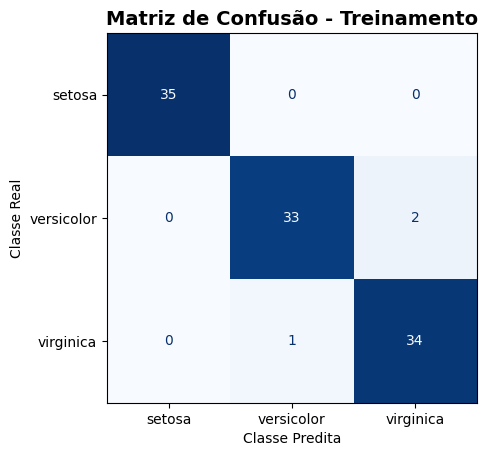

In [ ]:
cm_treino = confusion_matrix(y_treino, y_pred_treino)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_treino,
    display_labels=iris.target_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de Confusão - Treinamento",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

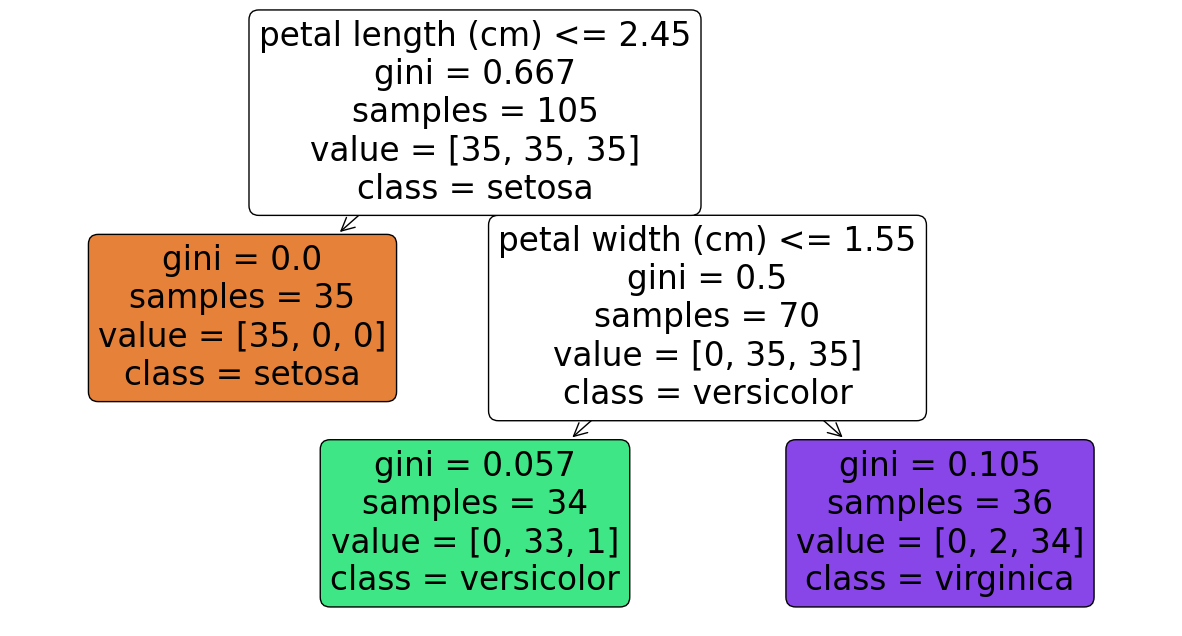

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))

plot_tree(
    modelo,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True
)

plt.show()

#Teste

In [ ]:
y_pred = modelo.predict(X_teste)

In [ ]:
# Calcular a acurácia
acuracia_teste = accuracy_score(y_teste, y_pred)

print("Acurácia no teste:", acuracia_teste)

Acurácia no teste: 0.8888888888888888


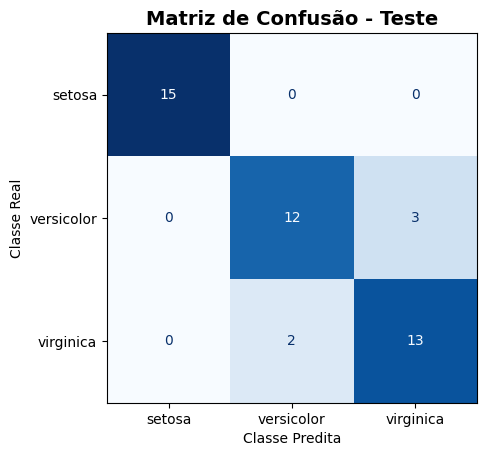

In [ ]:
cm_teste = confusion_matrix(y_teste, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_teste,
    display_labels=iris.target_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title(
    "Matriz de Confusão - Teste",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()